# Phase 6 — CAE結果レビューと検証計画（答案）

[本文](../docs/texts/phase6-cae-review.md) / [学習ログ](../docs/learning-log.md)

目的：出力の意味、収支、感度を別々に確かめ、判断できる用途と追加解析を説明する。
模擬データで学ぶ課題であり、実際のLS-DYNA計算・実務データ・商用ライセンスは不要。

## 提出と採点の範囲

- 5問・100点。記述・式・コードをこのNotebookにまとめる。目安は2〜3回に分けて合計2〜4時間。
- 本文の定義・式は既知として利用可。式の再導出や大量の手計算は不要。グラフは任意で、指定した数値表でも満点にできる。
- 問題が保証する条件は前提として使う。一般レビューへ切り替えるのは演習5で明示する。採点では各小問の指定観点だけを使う。
- 定型の入力検査とデータは配布済み。関数内部、表の作り方、指定された追加テストの入力は自分で設計する。
- `_ref` は配布実験用の値。関数は引数だけから計算し、外側の配列・基準値を参照しない。引数変更テストも指定する。実験セルで `_ref` を使うことは可。
- 未実装の関数は `NotImplementedError` とする。配布チェックは未実装ならその旨を表示する。**エラーなく全セルが動くことと、答案が完成したことは別。**

| 演習 | 内容 | 点 |
| --- | --- | --- |
| 1 | 平均処理とMises応力 | 15 |
| 2 | 力積とエネルギーの収支検証 | 30 |
| 3 | 関心量ごとのメッシュ感度 | 20 |
| 4 | 出力サンプリングと設定感度 | 20 |
| 5 | 用途を限定したレビューと追加計画 | 15 |

In [2]:
import numpy as np

# 配布する入力検査。ここを再実装する課題ではない。
def finite_array(value, shape=None):
    a = np.asarray(value, dtype=float)
    if not np.all(np.isfinite(a)) or (shape is not None and a.shape != shape):
        raise ValueError("有限値と指定形状が必要です")
    return a

def positive_scalar(value):
    a = finite_array(value, ())
    if a <= 0:
        raise ValueError("正のスカラーが必要です")
    return float(a)

def checked_history(data):
    t = finite_array(data["t"])
    if t.ndim != 1 or len(t) < 2 or not np.all(np.diff(t) > 0):
        raise ValueError("tは2点以上の単調増加1次元配列です")
    out = {"t": t}
    for key in ("drive", "support", "P", "K", "U", "D", "H", "W"):
        out[key] = finite_array(data[key], t.shape)
    if any(abs(out[key][0]) > 1e-12 for key in ("D", "H", "W")):
        raise ValueError("D, H, Wの初期値は0とします")
    return out

def check_when_ready(label, test):
    try:
        test()
    except NotImplementedError:
        print(label + ": 未実装（合格ではありません）")
    else:
        print(label + ": 配布チェック通過（記述と追加検証は別途必要）")

## 演習1：同じ「Mises平均」か（15点）

**保証する条件**：2点のCauchy応力は同じ時刻・同じ全体直交基底、単位MPa、外挿なし。重みは各1/2。違いは演算順序だけである。下の2点は「実在の一つの積分点にまとめてよい」とは保証しない。

1. `mises(stress)` を実装する。入力は対称な `(3,3)` 配列、戻り値はMPaの非負スカラー。二重縮約には全9成分を含める。（5点）
2. 各点の $q$、成分を平均した後の $q$、各点の $q$ の平均を表示し、結果が異なる理由を2〜4文で説明する。材料点の降伏判定に平均値を使う際の制約を一つ述べる。（5点）
3. 自分で非ゼロの静水圧応力と純せん断応力を一つずつ作る。前者で $|q|\le10^{-10}$ MPa、後者で $|q-\sqrt3|\tau||\le10^{-10}$ MPaを検証する。$\tau$ は自分が与えたせん断成分で、両側の対称成分を設定する。（5点）

既知としてよい式は本文2節の $q$ と偏差分解。三角不等式の証明は不要。

In [3]:
stress_samples_ref = np.array([np.diag([120., 0., 0.]), np.diag([-120., 0., 0.])])

def mises(stress):
    stress = finite_array(stress, (3, 3))
    if not np.allclose(stress, stress.T, atol=1e-12, rtol=0):
        raise ValueError("対称な応力テンソルが必要です")
    # TODO: 引数stressだけで計算する。
    s = stress-np.trace(stress)*np.eye(3, 3)/3.
    return np.sqrt(3.*(s*s).sum()/2.)

def check_mises():
    assert abs(mises(np.diag([90., 0., 0.])) - 90.) <= 1e-10

check_when_ready("演習1", check_mises)

# TODO: 2点の計算と、小問3の自作テスト。
n = stress_samples_ref.shape[0]
q = np.zeros(n)
for i in range(n):
    q[i] = mises(stress_samples_ref[i])
    print(f"点{i}のq [MPa]: {q[i]}")
print(f"平均応力のq [MPa]    : {mises((stress_samples_ref).mean(axis=0))}")
print(f"各点のqの平均 [MPa]  : {q.mean()}")

stress_hyd = np.diag([120., 120., 120.])
stress_shear = np.zeros_like(stress_hyd)
stress_shear[0, 1], stress_shear[1, 0] = 120., 120.
assert abs(mises(stress_hyd)) <= 1e-10
assert abs(mises(stress_shear)-np.sqrt(3)*abs(stress_shear[0, 1])) <= 1e-10

演習1: 配布チェック通過（記述と追加検証は別途必要）
点0のq [MPa]: 120.0
点1のq [MPa]: 120.0
平均応力のq [MPa]    : 0.0
各点のqの平均 [MPa]  : 120.0


### 演習1 答案

- 各点のq、平均の2通りの値：
  - 点0の$q$        : 120 MPa
  - 点1の$q$        : 120 MPa
  - 平均応力の$q$   : 0 MPa
  - 各点の$q$の平均 : 120 MPa
- 違いの理由と降伏判定の制約：
  - $q$は応力テンソルを一軸引張応力とみなせる座標系に変換したときの応力に相当し、方向の情報を失ったスカラーである。今回のケースでは各点の応力を平均すると引張と圧縮が相殺し、その$q$はゼロとなる。一方で、各点の応力をそれぞれ$q$に変換して方向の情報を落とした後で平均値をとると引張と圧縮は相殺されないため、値が異なる。
  - 材料境界での平均値は降伏判定を行う上で適当でない場合がある。
- 自作入力と確認結果：
  - 静水圧応力$\operatorname{diag}(120, 120, 120)$に対して、$|q|\le10^{-10}$ MPa
  - 純せん断応力$\begin{bmatrix}0&120&0\\120&0&0\\0&0&0\end{bmatrix}$に対して、$|q-\sqrt{3}|\tau||\le10^{-10}$ MPa

## 演習2：方向別の釣合いとエネルギー収支（30点）

**保証する条件**：同じ一定質量の対象、同じ時刻列、1方向の並進について検査する教育用台帳。力は対象に作用する向きへ符号を揃え、`drive + support` が全外力。質量流出入・要素削除・追加質量・熱交換はない。回転の釣合いは今回の範囲外。

| キー | 意味と単位 |
| --- | --- |
| `t` | 時刻、s |
| `drive`, `support` | 駆動側・支持側が対象へ加える力、N |
| `P` | 同方向の運動量、kg m/s |
| `K`, `U` | 運動・内部エネルギー、J（初期値を差し引く） |
| `D`, `H`, `W` | 開始時刻からの散逸、アワーグラス仕事、外力仕事、J |

`U` は `D,H` を含まず、`D,H,W` は初期値ゼロ。実ソルバの出力列への対応は問わない。基準値は $E_{\rm ref}=2000$ J、$F_{\rm ref}=2000$ N。検査許容値は全時刻でそれぞれ1%とする。

各列は収支検査の練習用に構成しており、共通の変位場・速度場・構成則を解いて生成したものではない。基準ケースの収支が一致しても、実現可能な構造応答や準静的性を証明したことにはならない。

1. `audit_history(data, energy_ref, force_ref)` を実装する。本文3・4節の符号付き $r_E,r_P$ を配列として返し、返却辞書のキーを `r_E`, `r_P`, `max_abs_r_E`, `max_abs_r_P`, `eta_K`, `eta_H` とする。末尾4値はスカラー。$\eta_K=\max_k K_k/energy\_ref$、$\eta_H=\max_k|H_k|/energy\_ref$。残差の最大値は必ず**絶対値を取ってから**最大にする。（12点）
2. 基準ケースと、出力転記不備を模した2ケースを検査し、最大残差2種・比率2種を表にする。2種類の収支について各々合否を記す。「一方が通るので他方もよい」とできない理由を述べる。（8点）
3. 検証用の入力を自分で設計する。非等間隔時刻でも $F(t)=a+bt$、$P(t)-P_0=at+bt^2/2$（開始時刻0）なら $\max|r_P|\le10^{-12}$ となること、`energy_ref`だけ2倍で $r_E,\eta_K,\eta_H$ が半分、`force_ref`だけ2倍で $r_P$ が半分となることを確かめる。$a$（N）、$b$（N/s）は自分で非ゼロ値を選ぶ。入力データが変更されないことも検証する。（6点）
4. 残差の異常を見つけた実データで、追加確認する項目を**力積について一つ、エネルギーについて一つ**挙げる。これは演習データの既知条件への疑義ではなく、同種の異常が出た一般ケースの診断候補である。原因を一意に断定しない。（4点）

In [4]:
energy_ref = 2000.  # J、配布実験の基準値
force_ref = 2000.   # N、配布実験の基準値
t_ref = np.linspace(0., 0.004, 9)
x_ref = t_ref / t_ref[-1]
P_ref = 100. * t_ref + 12500. * t_ref**2
K_ref = P_ref**2 / (2. * 0.02)  # 一定質量0.02 kgの並進として整合
W_ref = energy_ref * x_ref**2
D_ref = 5. * x_ref**2
H_ref = 20. * x_ref**2
history_ref = dict(
    t=t_ref.copy(), drive=1000. + 25000. * t_ref,
    support=np.full_like(t_ref, -900.), P=P_ref.copy(), K=K_ref.copy(),
    U=W_ref-K_ref-D_ref-H_ref, D=D_ref.copy(), H=H_ref.copy(), W=W_ref.copy())
histories_ref = {"baseline": {k: v.copy() for k, v in history_ref.items()}}
histories_ref["energy_export_error"] = {k: v.copy() for k, v in history_ref.items()}
histories_ref["energy_export_error"]["U"][4:] -= 160.
histories_ref["force_export_error"] = {k: v.copy() for k, v in history_ref.items()}
histories_ref["force_export_error"]["support"] += 100.

def audit_history(data, energy_ref, force_ref):
    data = checked_history(data)
    energy_ref = positive_scalar(energy_ref)
    force_ref = positive_scalar(force_ref)
    # TODO: 時間幅Tはdataから計算。r_Pの初期値は0。
    # 入力の配列へ代入せず、新しい結果を返す。
    r_E = (data["K"]+data["U"]+data["D"]+data["H"]-data["W"])/energy_ref
    J = np.zeros_like(data["t"])
    force_ext = data["drive"]+data["support"]
    for k in range(J.shape[0]-1):
        J[k+1] = J[k]+(force_ext[k+1]+force_ext[k])*(data["t"][k+1]-data["t"][k])/2.       
    r_P = (J-data["P"]+data["P"][0])/(force_ref*(data["t"][-1]-data["t"][0]))
    return dict(
        r_E=r_E, r_P=r_P, max_abs_r_E=np.max(np.abs(r_E)), max_abs_r_P=np.max(np.abs(r_P)),
        eta_K=np.max(data["K"])/energy_ref, eta_H=np.max(np.abs(data["H"]))/energy_ref)

def check_audit():
    out = audit_history(history_ref, energy_ref, force_ref)
    for key in ("r_E", "r_P"):
        assert np.asarray(out[key]).shape == t_ref.shape
        assert np.max(np.abs(out[key])) <= 1e-12
    for key in ("max_abs_r_E", "max_abs_r_P", "eta_K", "eta_H"):
        assert np.ndim(out[key]) == 0
        assert np.isfinite(out[key])
    assert abs(out["eta_H"] - 0.01) <= 1e-12

check_when_ready("演習2", check_audit)
# TODO: 3ケースの表と小問3の自作テスト。
print("ケース, max_abs_r_E, max_abs_r_P, eta_K, eta_H")
for k, v in histories_ref.items():
    out = audit_history(v, energy_ref, force_ref)
    print(k, *[out[key] for key in ("max_abs_r_E", "max_abs_r_P", "eta_K", "eta_H")])

a, b = 50., 50000.
t_nu = np.array([0.004*(1.-2.**(-i)) for i in range(8)]+[0.004])
x_nu = t_nu/t_nu[-1]
P_nu = a*t_nu+b*t_nu**2/2.
K_nu = P_nu**2/(2.*0.02)  # 一定質量0.02 kgの並進として整合
W_nu = energy_ref*x_nu**2
D_nu = 5.*x_nu**2
H_nu = 20.*x_nu**2
history_nu = dict(
    t=t_nu.copy(), drive=b*t_nu, support=np.full_like(t_nu, a), P=P_nu.copy(), K=K_nu.copy(),
    U=W_nu-K_nu-D_nu-H_nu, D=D_nu.copy(), H=H_nu.copy(), W=W_nu.copy())
history_nu_cp = history_nu.copy()
out_nu = audit_history(history_nu, energy_ref, force_ref)
out_nu_2er = audit_history(history_nu, energy_ref*2., force_ref)
out_nu_2fr = audit_history(history_nu, energy_ref, force_ref*2.)
assert out_nu["max_abs_r_P"] <= 1e-12
assert np.allclose(out_nu["r_E"], 2.*out_nu_2er["r_E"], rtol=0.01)
assert abs(out_nu["eta_K"]-2.*out_nu_2er["eta_K"]) <= 1e-12
assert abs(out_nu["eta_H"]-2.*out_nu_2er["eta_H"]) <= 1e-12
assert np.allclose(out_nu["r_P"], 2.*out_nu_2er["r_P"], rtol=0.01)
for k, v in history_nu.items():
    assert np.array_equal(v, history_nu_cp[k])

演習2: 配布チェック通過（記述と追加検証は別途必要）
ケース, max_abs_r_E, max_abs_r_P, eta_K, eta_H
baseline 0.0 1.3877787807814457e-17 0.0045 0.01
energy_export_error 0.08 1.3877787807814457e-17 0.0045 0.01
force_export_error 0.0 0.05 0.0045 0.01


### 演習2 答案

| ケース | max abs r_E (無次元) | max abs r_P (無次元) | eta_K (無次元) | eta_H (無次元) | エネルギー判定 | 力積判定 |
| --- | --- | --- | --- | --- | --- | --- |
| baseline | 0.0 | 1.3877787807814457e-17 | 0.0045 | 0.01 | 〇 | 〇 |
| energy_export_error | 0.08 | 1.3877787807814457e-17 | 0.0045 | 0.01 | × | 〇 |
| force_export_error | 0.0 | 0.05 | 0.0045 | 0.01 | 〇 | × |
- 2種類の収支を別々に見る理由：
  本演習では、内部エネルギーの転記不備はエネルギー収支、支持側外力の転記不備は力積収支にしか影響していない。一般にエネルギー収支はスカラー、力積収支は方向別の点検となるため、それぞれの収支を点検する必要がある。
- 追加テストの入力・結果、入力保存の結果：
  - 非等間隔時刻列(0, 0.002, 0.003, 0.0035, 0.00375, 0.003875, 0.0039375, 0.00396875, 0.004) s、$a=50$ N、$b=50000$ N/sとすると、$\max|r_P|\le10^{-12}$、`energy_ref`だけ2倍で $r_E,\eta_K,\eta_H$ が半分、`force_ref`だけ2倍で $r_P$ が半分となる。
  - 入力`history_nu`はすべて保存されている。
- 一般ケースでの追加確認（力積／エネルギー）：
  - 力積：欠けている力がないか
  - エネルギー：散逸を内部エネルギーとして二重計上していないか

## 演習3：何がメッシュに依存しているか（20点）

**保証する条件**：準静的押込みの模擬比較。材料・形状・負荷・接触・要素形式と出力処理は固定し、要素寸法だけ変更した。全ケースを同じ押込み変位5 mmで評価。`reaction` は駆動点反力の大きさ、`remote_stress` は固定した遠方断面の面積平均軸応力、`corner_mises` と `max_eps` は同じ角部領域の非平均化積分点値の空間最大。EPSはPhase 5の累積相当塑性ひずみ。時間ピークではない。

1. `mesh_changes(values, floor)` を実装し、連続する3組の $d_Q=|Q_f-Q_c|$ と $\delta_Q=|Q_f-Q_c|/\max(|Q_f|,floor)$ をキー `absolute`, `relative` の配列で返す。4関心量すべてについて表を作る。`floor` はそれぞれ1 N、1 MPa、1 MPa、$10^{-6}$。（8点）
2. 最後の2メッシュ間で $\delta_Q\le0.01$ を満たすか**関心量ごと**に答える。全3組の傾向にも触れ、これは厳密解との誤差を保証する判定ではないことを説明する。（6点）
3. 「反力を比較する用途」と「角部の破断を認定する用途」の2つを分け、この表から判断できること・不足する根拠を述べる。局所値の増大の原因候補を二つ挙げるが、この表だけで特異性や破断を断定しない。（6点）

In [5]:
mesh_ref = {
    "h_mm": np.array([8., 4., 2., 1.]),
    "reaction": np.array([10000., 10800., 11000., 11050.]),
    "remote_stress": np.array([180., 190., 194., 195.]),
    "corner_mises": np.array([300., 420., 580., 800.]),
    "max_eps": np.array([0.04, 0.07, 0.12, 0.20]),
}
floors_ref = dict(reaction=1., remote_stress=1., corner_mises=1., max_eps=1e-6)

def mesh_changes(values, floor):
    values = finite_array(values)
    floor = positive_scalar(floor)
    if values.ndim != 1 or len(values) < 2:
        raise ValueError("2点以上の1次元配列が必要です")
    # TODO: valuesは粗いメッシュから細かいメッシュの順。
    absolute = np.array([abs(values[i+1]-values[i]) for i in range(len(values)-1)])
    relative = absolute/np.array([max(abs(values[i+1]), floor) for i in range(len(values)-1)])
    return dict(absolute=absolute, relative=relative)

def check_mesh():
    out = mesh_changes([1., 0., -1.], 0.5)
    assert np.allclose(out["absolute"], [1., 1.], atol=1e-12, rtol=0)
    assert np.allclose(out["relative"], [2., 1.], atol=1e-12, rtol=0)

check_when_ready("演習3", check_mesh)
# TODO: 4関心量×3組の表を作る。
print("要素寸法変化 [mm]", *[f", {mesh_ref['h_mm'][i]}→{mesh_ref['h_mm'][i+1]}" for i in range(len(mesh_ref['h_mm'])-1)])
for k, v in mesh_ref.items():
    if k=="h_mm":
        continue
    out = mesh_changes(v, floors_ref[k])
    print(f"{k}_absolute, ", *out["absolute"])
    print(f"{k}_relative, ", *out["relative"])


演習3: 配布チェック通過（記述と追加検証は別途必要）
要素寸法変化 [mm] , 8.0→4.0 , 4.0→2.0 , 2.0→1.0
reaction_absolute,  800.0 200.0 50.0
reaction_relative,  0.07407407407407407 0.01818181818181818 0.004524886877828055
remote_stress_absolute,  10.0 4.0 1.0
remote_stress_relative,  0.05263157894736842 0.020618556701030927 0.005128205128205128
corner_mises_absolute,  120.0 160.0 220.0
corner_mises_relative,  0.2857142857142857 0.27586206896551724 0.275
max_eps_absolute,  0.030000000000000006 0.04999999999999999 0.08000000000000002
max_eps_relative,  0.4285714285714286 0.4166666666666666 0.4000000000000001


### 演習3 答案

- 比較表（コード出力でも可）と各量の判定：コード出力の比較表(relativeに関しては無次元)より、駆動点反力の大きさおよび遠方断面の面積平均軸応力については最後の2メッシュ間で $\delta_Q\le0.01$ を満たすが、角部での相当応力およびEPSはそうでない。
- 全3組の傾向、厳密誤差との違い：
  - メッシュの細分化に伴い、反力と遠方断面の応力は収束していくが、角部での相当応力とEPSは増加量が大きくなり、相対差は反力および遠方断面の応力と比較してゆっくりと減衰する。
  - メッシュ細分化により改善するのは形状再現性であり、例えば要素内での積分精度が不十分である場合などには、メッシュ細分化だけで厳密解に近づくとは限らない。
- 反力比較への利用範囲：今回の要素寸法変化の範囲で反力を評価するうえでは、荷重導入部付近の特異性は表れていないと判断できる。
- 角部の判断に足りない根拠と原因候補2つ：軟化則のメッシュ依存性が判断根拠として不足している。例えば、単位面積あたりの破壊エネルギーが要素寸法に応じて変化するモデルを用いていた場合は、破断までの塑性ひずみが大きくなる。また、ひずみが大きい要素が軟化してさらにひずむというように特定の要素にひずみが集中している可能性もある。

## 演習4：ピークを逃す原因を切り分ける（20点）

### A. 出力間隔だけの実験（10点）

スカラーの力信号 $F(t)=100+900\exp[-((t-0.55)/0.025)^2]$ Nを考える。$t$ はs、範囲は0〜1 s。これは解析解を与えた信号であり、FEMや時間積分の結果ではない。

1. 出力間隔0.1 sと0.005 sで0〜1 s（両端含む）をサンプルし、それぞれ最大値とその時刻を求める。真の最大値1000 Nに対する相対的な過小評価 $(1000-\max F_k)/1000$ を表にする。（5点）
2. 粗い値を細かい時刻へ線形補間して最大値を比較する。出力間隔、ソルバ時間刻み、負荷時間のうちこの実験で検証したのはどれか、補間だけで不足する理由とともに述べる。（5点）

### B. 準静的解析の設定比較（10点）

次の表は別の模擬CAE比較で、Aの力信号とは無関係。全ケースの反力は同じ押込み変位5 mmで評価。速度非依存・等温材料、同じ変位経路、メッシュ、接触、出力処理、十分に細かい出力間隔を保証する。質量は各ケースの開始時に追加し、途中追加なし。比率は全ケースで同じ固定 $E_{\rm ref}$ を使う。**基準解析が厳密解であること、局所変形が正しいことは保証しない。**

| ケース | 負荷時間s | 全体追加質量比 | 関心部品追加質量比 | 反力N | eta_K |
| --- | --- | --- | --- | --- | --- |
| A | 0.02 | 0.01 | 0.30 | 12000 | 0.04 |
| B | 0.04 | 0.01 | 0.30 | 11100 | 0.01 |
| C | 0.04 | 0.00 | 0.00 | 10800 | 0.008 |

3. A→B、B→Cの反力差を $|F_{\rm new}-F_{\rm old}|/|F_{\rm new}|$ で計算し、各変更の感度を2%以下という暫定基準で判定する。どちらが負荷時間、どちらが追加質量の感度か明記する。（5点）
4. 全体追加質量1%・eta_Kが5%未満という二条件だけでAを採用できない理由を、この表の数値に基づいて述べる。次に見る**局所出力を一つ**と、その観測目的を書く。（5点）

出力間隔 [s], 最大値 [N], 時刻 [s], 過小評価 [無次元]
0.1, 116.48407499986064, 0.5, 0.8835159250001393
0.005, 1000.0, 0.55, 0.0
線形補間
最大値 [N]: 116.48407499986064, 時刻 [s]: 0.5, 過小評価 [無次元]: 0.8835159250001393


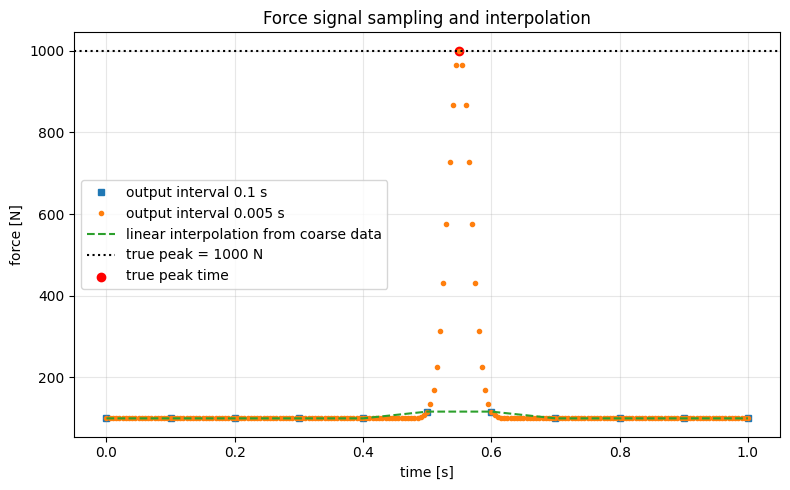

A→Bの反力差 [無次元]:  0.08108108108108109
B→Cの反力差 [無次元]:  0.027777777777777776


In [7]:
def force_signal(t):
    t = finite_array(t)
    return 100. + 900. * np.exp(-((t - 0.55) / 0.025)**2)

# TODO: Aのサンプリング表、np.interp等による補間比較。
t_c = np.linspace(0., 1., 11)
t_f = np.linspace(0., 1., 201)
force_c = force_signal(t_c)
force_f = force_signal(t_f)
print("出力間隔 [s], 最大値 [N], 時刻 [s], 過小評価 [無次元]")
print(f"0.1, {force_c.max()}, {force_c.argmax()*0.1}, {(1000.-force_c.max())/1000.}")
print(f"0.005, {force_f.max()}, {force_f.argmax()*0.005}, {(1000.-force_f.max())/1000.}")

force_interp = np.interp(t_f, t_c, force_c)
print("線形補間")
print(f"最大値 [N]: {force_interp.max()}, 時刻 [s]: {force_interp.argmax()*0.005}, 過小評価 [無次元]: {(1000.-force_interp.max())/1000.}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(t_c, force_c, "s", ms=5, label="output interval 0.1 s")
plt.plot(t_f, force_f, "o", ms=3, label="output interval 0.005 s")
plt.plot(t_f, force_interp, "--", label="linear interpolation from coarse data")
plt.axhline(1000.0, color="black", linestyle=":", label="true peak = 1000 N")
plt.scatter(0.55, 1000.0, color="red", label="true peak time")
plt.xlabel("time [s]")
plt.ylabel("force [N]")
plt.title("Force signal sampling and interpolation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# TODO: Bの2組の反力差。関数化は任意。
force_st = [12000., 11100., 10800.]
print("A→Bの反力差 [無次元]: ", abs((force_st[1]-force_st[0])/force_st[1]))
print("B→Cの反力差 [無次元]: ", abs((force_st[2]-force_st[1])/force_st[2]))

### 演習4 答案

- A：最大値・時刻・過小評価の表：

| 出力間隔 [s] | 最大値 [N] | 時刻 [s] | 過小評価 [無次元] |
| --- | --- | --- | --- |
| 0.1 | 116.48407499986064 | 0.5 | 0.8835159250001393 |
| 0.005 | 1000.0 | 0.55 | 0.0 |

- 線形補間の結果と、検証した量／していない量：線形補間しても粗いサンプリングでとらえた最大値は変わらない。ここで検証されている量は出力間隔であり、ソルバ時間刻みや負荷時間は変わっておらず、ソルバが最大値をとらえた時刻をサンプルしない限りは線形補間による最大値の復元は不可能。
- B：反力差2組の数値・暫定判定と変えた条件：

| ケース | 反力差 [無次元] | 暫定判定(2%以下) | 変更条件 |
| --- | --- | --- | --- |
| A→B | 0.08108108108108109 | × | 負荷時間 |
| B→C | 0.027777777777777776 | × | 追加質量 |

- Aの採否に不足する根拠、次に見る局所出力と目的：
  - 負荷時間に対する反力の感度はおよそ8%であり、これを許容できるかと合わせて判断する必要がある。
  - 慣性の影響が準静的近似の前提を壊していないかを確認するために、変形モードも確認する。

## 演習5：一般レビューへ切り替える（15点）

**ここからは新しい未確認ケースである。演習1〜4の保証条件と数値は引き継がない。**
依頼者から「LS-DYNAのシェル部品の準静的押込み解析で、最大Mises 800 MPa、EPS 0.2。計算は正常終了。押込み5 mmでの反力を設計案比較に使いたい。角部が破断するかも知りたい」とだけ伝えられた。
入力デッキ、材料定義、ソルバ版、積分点位置、出力処理、時刻歴、比較実験は未提供。実物データを探したり、使用版を推測したりする課題ではない。

1. 最初に求める情報を、**出力量の定義、位置・表示処理、材料・荷重条件、数値設定・収支**の4観点について各一つ挙げる。情報がどの判断に必要かも記す。（4点）
2. 現段階の反力比較と破断判定をそれぞれ「支持できる／保留」から選び、根拠を述べる。最大MisesとEPSだけでは足りない理由を含める。（4点）
3. 追加確認を優先順に3件計画する。各件を「仮説／一つだけ変更または取得する条件／固定する条件／観測量／事前の判定基準／判定できる範囲」の表にする。少なくとも一件は数値感度、一件は独立実験との比較とし、残り一件は自分で選ぶ。数値許容値は練習用として自分で設定し、その理由を1文付ける。実験の取得可能性や不確かさが未確認なら、それも記して条件付きの計画にする。（7点）

本文9節の形式を参考にしてよい。短い表と文章で十分であり、キーワードの具体的な設定値や新たなFEM実装は要求しない。

### 演習5 答案

| 確認観点 | 求める情報 | 必要な判断 |
| --- | --- | --- |
| 出力量の定義 | EPSの定義 | 破断判定に使えるか |
| 位置・表示処理 | 最大Misesの発生位置 | 拘束部などの特異な点での値でないか |
| 材料・荷重条件 | 負荷時間 | 慣性の影響が残っていないか |
| 数値設定・収支 | 出力間隔 | 最大Misesピークをとらえているか |

- 反力比較の現時点の判断と理由：変形モードが同一の範囲で相対比較するだけであれば支持
- 角部の破断判定の現時点の判断と理由：局所ピークを破断判定閾値と比較できるかの根拠が不十分であるため保留

| 優先順 | 仮説 | 変更・取得する条件 | 固定する条件 | 観測量 | 事前基準と理由 | 判断の範囲 |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 計算された最大Misesピークを出力できていない | 出力間隔 | ソルバ時間刻み | 最大Mises | (要素サイズなどの諸条件によるが)10%程度なら数値的に揺らぐ可能性があると考え、10%以上変動しないか | 最も危険な時刻の状態を出力できている |
| 2 | EPSが破断判定に適していない | 実測で破断した部品のひずみ | 材料 | 累積相当塑性ひずみ | 実測での破断を予測できるかを最終的なKPIとするため、破断判定正答率95%以上 | 特定の材料、実験条件での破断判定が計算したEPSで実施できる |
| 3 | 慣性の影響が残っており準静的解析の前提を壊している | 負荷時間 | 出力間隔 | 変形モード | 力の伝達経路が変わってしまうと関心のある現象とは異なるものを見てしまう可能性があるため、変形モードが一致しているか | 準静的解析の前提を壊していない |

## 提出前と振り返り

- [ ] 未実装を埋め、先頭から再実行した。配布チェック以外の指定実験と記述もある。
- [ ] 比率は無次元値か%かを明記し、単位付きの値と区別した。
- [ ] 保証された条件と、一般レビューの未確認事項を分けた。

学習者メモ（採点対象外）：
- 比較式・既知条件・一般レビューへの切替は明確だったか：
- 手計算の負担、実装の自由度、配布チェックは適切だったか：
- 次に理解したいこと：

[学習ログ](../docs/learning-log.md)のPhase 6枠は、解答とフィードバックの確認時に更新する。